In [1]:
import pandas as pd

# Basic
df = pd.read_csv("/scratch/prj0000000262/Sanwa/2025.12.16 Terminal_mapped_output_YX.csv")

print(df.head())
print(df.shape)


   Mould  Cavity  production_cycle  injection_time  switchover_position  \
0      2       5             36.76            1.69                 9.99   
1      2       6             36.76            1.69                 9.99   
2      2       7             36.76            1.69                 9.99   
3      2       8             36.76            1.69                 9.99   
4      2       5             36.77            1.69                 9.99   

   max_injection_pressure  switchover_pressure  end_of_packing_stroke  \
0                   158.6                 1222                   3.24   
1                   158.6                 1222                   3.24   
2                   158.6                 1222                   3.24   
3                   158.6                 1222                   3.24   
4                   157.3                 1216                   3.22   

   plastification_time  nozzle_temperature  ...  feeder_temperature  ROI_32  \
0                 8.39         

# Feature Selection


=== Target: ROI_13 ===
Train CV R^2: mean=-0.270, std=0.086

Top 10 features by PERMUTATION importance for ROI_13:
                  feature  perm_importance_mean  perm_importance_std
           injection_time              0.023625             0.021348
   max_injection_pressure             -0.000203             0.002918
  barrel_rear_temperature             -0.013364             0.008067
      switchover_pressure             -0.021894             0.005930
       feeder_temperature             -0.022097             0.007493
         production_cycle             -0.023765             0.007676
                  Mould_1             -0.026469             0.006764
barrel_center_temperature             -0.027109             0.009320
       nozzle_temperature             -0.035467             0.008880
      switchover_position             -0.036907             0.012106


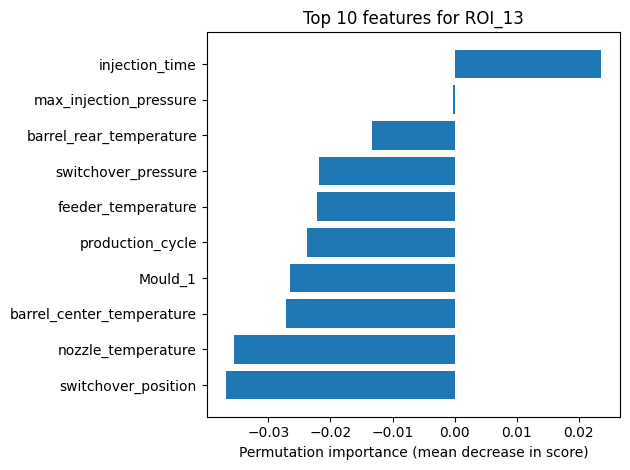


=== Target: ROI_16 ===
Train CV R^2: mean=-0.124, std=0.056

Top 10 features by PERMUTATION importance for ROI_16:
                  feature  perm_importance_mean  perm_importance_std
           injection_time              0.020065             0.022925
   max_injection_pressure             -0.002892             0.002718
      switchover_pressure             -0.034247             0.010379
       feeder_temperature             -0.039982             0.010770
         production_cycle             -0.044809             0.017371
      switchover_position             -0.055701             0.014587
                  Mould_1             -0.058073             0.011518
                  Mould_2             -0.058355             0.018009
barrel_center_temperature             -0.058559             0.021426
       nozzle_temperature             -0.060574             0.013452


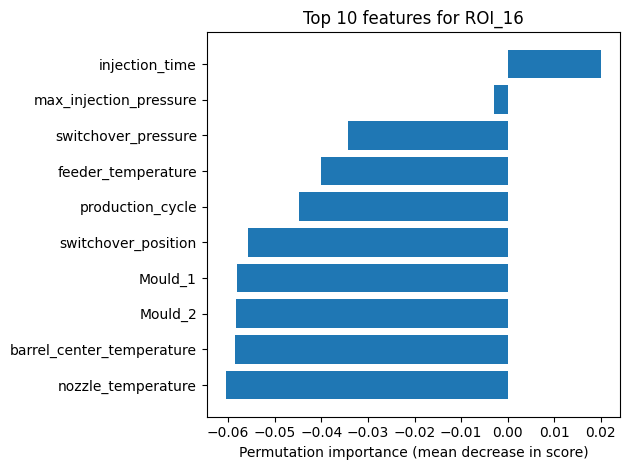


=== Target: ROI_18 ===
Train CV R^2: mean=-0.088, std=0.043

Top 10 features by PERMUTATION importance for ROI_18:
                  feature  perm_importance_mean  perm_importance_std
           injection_time              0.010571             0.022897
   max_injection_pressure             -0.011373             0.006045
      switchover_pressure             -0.011576             0.006304
      switchover_position             -0.013669             0.005476
         production_cycle             -0.017225             0.006849
  barrel_rear_temperature             -0.020529             0.006743
       nozzle_temperature             -0.028280             0.009543
barrel_center_temperature             -0.030754             0.009106
                  Mould_2             -0.037134             0.020089
    end_of_packing_stroke             -0.038675             0.014476


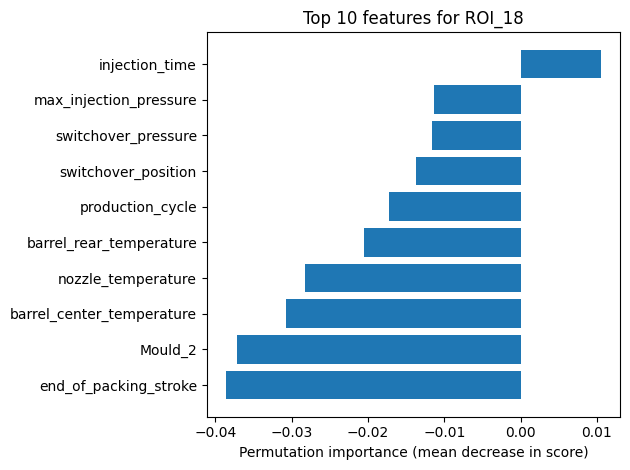

ROI_13 -> ['injection_time', 'max_injection_pressure', 'barrel_rear_temperature', 'switchover_pressure', 'feeder_temperature', 'production_cycle', 'Mould_1', 'barrel_center_temperature', 'nozzle_temperature', 'switchover_position']
ROI_16 -> ['injection_time', 'max_injection_pressure', 'switchover_pressure', 'feeder_temperature', 'production_cycle', 'switchover_position', 'Mould_1', 'Mould_2', 'barrel_center_temperature', 'nozzle_temperature']
ROI_18 -> ['injection_time', 'max_injection_pressure', 'switchover_pressure', 'switchover_position', 'production_cycle', 'barrel_rear_temperature', 'nozzle_temperature', 'barrel_center_temperature', 'Mould_2', 'end_of_packing_stroke']


In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

TARGETS = ["ROI_13", "ROI_16", "ROI_18"]

def rf_feature_selection_per_target(
    df: pd.DataFrame,
    target: str,
    test_size: float = 0.2,
    random_state: int = 42,
    n_estimators: int = 800,
    top_k: int = 10,
    plot: bool = True,
):
    # --- Split X/y
    X = df.drop(columns=TARGETS)
    y = df[target].values

    # Treat Mould & Cavity as categorical (recommended)
    categorical_cols = [c for c in ["Mould", "Cavity"] if c in X.columns]
    numeric_cols = [c for c in X.columns if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]), numeric_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), categorical_cols),
        ],
        remainder="drop"
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        max_features="sqrt",
        min_samples_leaf=2,
    )

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("rf", model),
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # --- Fit
    pipe.fit(X_train, y_train)

    # --- (Optional) quick CV score to sanity check model usefulness
    cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    print(f"\n=== Target: {target} ===")
    print(f"Train CV R^2: mean={cv_r2.mean():.3f}, std={cv_r2.std():.3f}")

    # --- Get transformed feature names
    prep = pipe.named_steps["prep"]
    feature_names = []
    if len(numeric_cols) > 0:
        feature_names.extend(numeric_cols)

    if len(categorical_cols) > 0:
        ohe = prep.named_transformers_["cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(ohe_names)

    feature_names = np.array(feature_names)

    # --- Impurity-based importance (RF built-in)
    rf = pipe.named_steps["rf"]
    impurity_imp = rf.feature_importances_
    impurity_rank = np.argsort(impurity_imp)[::-1]
    impurity_df = pd.DataFrame({
        "feature": feature_names[impurity_rank],
        "importance": impurity_imp[impurity_rank],
    })

    # --- Permutation importance (recommended)
    perm = permutation_importance(
        pipe, X_test, y_test,
        n_repeats=30,
        random_state=random_state,
        n_jobs=-1
    )
    perm_imp = perm.importances_mean
    perm_std = perm.importances_std
    perm_rank = np.argsort(perm_imp)[::-1]
    perm_df = pd.DataFrame({
        "feature": feature_names[perm_rank],
        "perm_importance_mean": perm_imp[perm_rank],
        "perm_importance_std": perm_std[perm_rank],
    })

    # --- Select top_k using permutation importance
    selected = perm_df.head(top_k)["feature"].tolist()

    print(f"\nTop {top_k} features by PERMUTATION importance for {target}:")
    print(perm_df.head(top_k).to_string(index=False))

    if plot:
        top_plot = perm_df.head(top_k).iloc[::-1]  # reverse for nicer horizontal plot
        plt.figure()
        plt.barh(top_plot["feature"], top_plot["perm_importance_mean"])
        plt.xlabel("Permutation importance (mean decrease in score)")
        plt.title(f"Top {top_k} features for {target}")
        plt.tight_layout()
        plt.show()

    return {
        "target": target,
        "cv_r2_mean": float(cv_r2.mean()),
        "cv_r2_std": float(cv_r2.std()),
        "perm_importance": perm_df,
        "impurity_importance": impurity_df,
        "selected_features_topk_perm": selected,
        "pipeline": pipe,
    }

# ---- Run for each ROI target
results = {}
for t in TARGETS:
    results[t] = rf_feature_selection_per_target(
        df,
        target=t,
        top_k=10,      # change if you want top 5 / top 20
        plot=True
    )

# Example: get the selected features
for t in TARGETS:
    print(t, "->", results[t]["selected_features_topk_perm"])


In [ ]:
'injection_time', 'max_injection_pressure', 'switchover_pressure', 'switchover_position', 'production_cycle', 'Mould',  'Cavity'

In [107]:
roi_cols = ['ROI_35','ROI_37','ROI_39','ROI_41','ROI_43','ROI_45','ROI_47','ROI_49']
df_no_roi = df.drop(columns=roi_cols)
                   
X = df_no_roi.to_numpy()

In [14]:
keep_cols = [
    "injection_time",
    "max_injection_pressure",
    "switchover_pressure",
    "switchover_position",
    "production_cycle",
    "Mould",
    "Cavity",
]

df = df[keep_cols].copy()
X = df.to_numpy()

In [108]:
# If column name is the integer 14
roi = "ROI_49"
y = df[roi].to_numpy()

print(y.shape)   # (508,)
print(type(y))   # numpy.ndarray


(512,)
<class 'numpy.ndarray'>


In [109]:
import numpy as np

# X: (508, 14)
X = X.astype(np.float32, copy=False)

# Make (508, 14, 1024) by repeating along a new last axis
X_3d = np.repeat(X[:, :, None], 1024, axis=2)

print(X_3d.shape)  # (508, 14, 1024)


(512, 15, 1024)


In [110]:
X_3d

array([[[  2.  ,   2.  ,   2.  , ...,   2.  ,   2.  ,   2.  ],
        [  5.  ,   5.  ,   5.  , ...,   5.  ,   5.  ,   5.  ],
        [ 36.76,  36.76,  36.76, ...,  36.76,  36.76,  36.76],
        ...,
        [245.2 , 245.2 , 245.2 , ..., 245.2 , 245.2 , 245.2 ],
        [ 59.2 ,  59.2 ,  59.2 , ...,  59.2 ,  59.2 ,  59.2 ],
        [ 90.  ,  90.  ,  90.  , ...,  90.  ,  90.  ,  90.  ]],

       [[  2.  ,   2.  ,   2.  , ...,   2.  ,   2.  ,   2.  ],
        [  6.  ,   6.  ,   6.  , ...,   6.  ,   6.  ,   6.  ],
        [ 36.76,  36.76,  36.76, ...,  36.76,  36.76,  36.76],
        ...,
        [245.2 , 245.2 , 245.2 , ..., 245.2 , 245.2 , 245.2 ],
        [ 59.2 ,  59.2 ,  59.2 , ...,  59.2 ,  59.2 ,  59.2 ],
        [ 87.  ,  87.  ,  87.  , ...,  87.  ,  87.  ,  87.  ]],

       [[  2.  ,   2.  ,   2.  , ...,   2.  ,   2.  ,   2.  ],
        [  7.  ,   7.  ,   7.  , ...,   7.  ,   7.  ,   7.  ],
        [ 36.76,  36.76,  36.76, ...,  36.76,  36.76,  36.76],
        ...,
        [245

In [111]:
import numpy as np
import pandas as pd
from pathlib import Path

assert X_3d.ndim == 3  # (N, 14, 1024)
N, C, L = X_3d.shape

df = pd.DataFrame({
    "samples": [[X_3d[i, j, :].copy() for j in range(C)] for i in range(N)],  # list of C arrays (L,)
    "labels": y
})

# Base directory + make sure ROI folder exists
base_dir = Path("/scratch/prj0000000262/Sanwa") / roi
base_dir.mkdir(parents=True, exist_ok=True)

out_path = base_dir / "dataset.parquet"
df.to_parquet(str(out_path), engine="pyarrow", index=False)

# Verify
df2 = pd.read_parquet(str(out_path))
x0 = df2.at[0, "samples"]  # first row's "samples"


In [112]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedShuffleSplit

# ---- config ----

base = f"/scratch/prj0000000262/Sanwa/{roi}"

in_path   = f"{base}/dataset.parquet"
out_train = f"{base}/train_1p.parquet"
out_val   = f"{base}/val.parquet"
out_test  = f"{base}/test.parquet"


K = 3
seed = 42
n_init = 20
# ----------------

df = pd.read_parquet(in_path)

# --- labels ---
y = df["labels"].to_numpy()
y = y.astype(np.float32)
mask = ~np.isnan(y)
if mask.sum() != len(df):
    df = df.loc[mask].reset_index(drop=True)
    y = df["labels"].to_numpy().astype(np.float32)

Y = y.reshape(-1, 1)

# --- KMeans on labels (1D clustering) ---
km = KMeans(n_clusters=K, random_state=seed, n_init=n_init)
cluster_raw = km.fit_predict(Y)
centers = km.cluster_centers_.reshape(-1)

# Relabel clusters by ascending center so cluster IDs are ordered by label value
order = np.argsort(centers)
inv_order = np.zeros_like(order)
inv_order[order] = np.arange(len(order))
cluster = inv_order[cluster_raw]
centers_sorted = centers[order]

df["cluster"] = cluster

# Sanity: cluster sizes
counts = np.bincount(cluster, minlength=K)
print("=== Cluster centers (sorted) & counts ===")
for i in range(K):
    print(f"cluster {i}: center={centers_sorted[i]:.6f}, n={counts[i]}")
print("Min cluster size:", counts.min())

# If any cluster is too small, stratified split may be impossible
# (You need enough samples per cluster to appear in train/val/test.)
if counts.min() < 3:
    raise ValueError(
        f"Some cluster has <3 samples (min={counts.min()}). "
        "Cannot guarantee all 3 splits contain all clusters."
    )

# --- Stratified split: 60/20/20 ---
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.40, random_state=seed)
train_idx, temp_idx = next(sss1.split(df, df["cluster"]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_temp  = df.iloc[temp_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)  # split 40% into 20/20
val_idx, test_idx = next(sss2.split(df_temp, df_temp["cluster"]))

df_val  = df_temp.iloc[val_idx].reset_index(drop=True)
df_test = df_temp.iloc[test_idx].reset_index(drop=True)

# --- Verify each split has all K clusters ---
def show_split(name, d):
    c = d["cluster"].value_counts().sort_index()
    missing = [i for i in range(K) if i not in c.index]
    print(f"\n[{name}] n={len(d)}")
    print(c.to_string())
    if missing:
        print("MISSING CLUSTERS:", missing)
    else:
        print("All clusters present ✅")

show_split("TRAIN", df_train)
show_split("VAL", df_val)
show_split("TEST", df_test)

# --- Save ---
df_train.to_parquet(out_train, index=False)
df_val.to_parquet(out_val, index=False)
df_test.to_parquet(out_test, index=False)

print("\nSaved:")
print(" ", out_train)
print(" ", out_val)
print(" ", out_test)


=== Cluster centers (sorted) & counts ===
cluster 0: center=618.985596, n=206
cluster 1: center=1065.123657, n=194
cluster 2: center=1462.428589, n=112
Min cluster size: 112

[TRAIN] n=307
cluster
0    124
1    116
2     67
All clusters present ✅

[VAL] n=102
cluster
0    41
1    39
2    22
All clusters present ✅

[TEST] n=103
cluster
0    41
1    39
2    23
All clusters present ✅

Saved:
  /scratch/prj0000000262/Sanwa/ROI_49/train_1p.parquet
  /scratch/prj0000000262/Sanwa/ROI_49/val.parquet
  /scratch/prj0000000262/Sanwa/ROI_49/test.parquet
